# Notebook 02: Preprocesamiento de Datos y Balanceo con Borderline-SMOTE

Este notebook implementa el preprocesamiento de datos completo y la preparación para machine learning, integrando las siguientes etapas metodológicas:

*   **Paso 3**: Limpieza de datos (remoción de duplicados, imputación de nulos e infinitos).
*   **Paso 4**: Mapeo estandarizado de clases (34 etiquetas lógicas a 8 categorías de red).
*   **Paso 5**: Partición de datos en Entrenamiento (70%), Validación (15%) y Prueba (15%) de forma estratificada.
*   **Paso 6**: Búsqueda e importancia de características predictivas utilizando un Random Forest Classifier.
*   **Paso 7**: Normalización robusta mediante `RobustScaler` (evitando fuga de datos al entrenar el escalador solo sobre Train).
*   **Paso 8**: Balanceo de clases aplicando **Borderline-SMOTE** en el conjunto de entrenamiento.

In [2]:
import os
import pandas as pd
import numpy as np
import json
import joblib
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import BorderlineSMOTE

# Cambiar el directorio de trabajo a la raíz si el notebook se ejecuta desde 'notebooks'
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
print(f"Directorio de trabajo activo: {os.getcwd()}")

# Estilo gráfico premium
sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.figsize'] = (12, 6)

# Asegurar existencia de carpetas
os.makedirs("data/processed", exist_ok=True)
os.makedirs("data/balanced", exist_ok=True)
os.makedirs("results/figures", exist_ok=True)
os.makedirs("models", exist_ok=True)

Directorio de trabajo activo: /home/carmen/tesis_iot


In [3]:
# Paso 1: Cargar el dataset consolidado (salida del Paso 1)
df_path = "data/processed/dataset_consolidado.csv"
print("Cargando dataset consolidado...")
df = pd.read_csv(df_path)
print(f"¡Cargado con éxito! Filas iniciales: {len(df):,}, Columnas: {df.shape[1]}")

Cargando dataset consolidado...
¡Cargado con éxito! Filas iniciales: 2,954,555, Columnas: 40


## 1. Limpieza de Datos (Paso 3)

Limpiamos nulos, infinitos y duplicados en el dataset de base antes de entrenar cualquier modelo para asegurar la estabilidad numérica.

In [4]:
# A. Eliminar columnas redundantes (AVG, Tot sum, Min)
cols_redundantes = ['AVG', 'Tot sum', 'Min']
cols_a_eliminar = [c for c in cols_redundantes if c in df.columns]
print(f"Eliminando columnas redundantes: {cols_a_eliminar}")
df.drop(columns=cols_a_eliminar, inplace=True)

# B. Eliminar filas con infinitos en 'Rate'
if 'Rate' in df.columns:
    df = df[~np.isinf(df['Rate'])]
    print("Filas con valores infinitos en 'Rate' eliminadas.")

# C. Eliminar filas con nulos en 'Std' y 'Variance'
df = df[df['Std'].notna() & df['Variance'].notna()]
print("Filas con valores nulos eliminadas.")

# D. Eliminar registros duplicados
df.drop_duplicates(inplace=True)
print(f"Registros restantes tras la limpieza: {len(df):,}")

Eliminando columnas redundantes: ['AVG', 'Tot sum', 'Min']
Filas con valores infinitos en 'Rate' eliminadas.
Filas con valores nulos eliminadas.
Registros restantes tras la limpieza: 2,515,882


## 2. Mapeo de Clases a 8 Categorías (Paso 4)

In [5]:
clases_a_categorias = {
    'DDOS-ACK_FRAGMENTATION': 'DDoS', 'DDOS-HTTP_FLOOD': 'DDoS', 'DDOS-ICMP_FLOOD': 'DDoS',
    'DDOS-ICMP_FRAGMENTATION': 'DDoS', 'DDOS-PSHACK_FLOOD': 'DDoS', 'DDOS-RSTFINFLOOD': 'DDoS',
    'DDOS-SLOWLORIS': 'DDoS', 'DDOS-SYN_FLOOD': 'DDoS', 'DDOS-SYNONYMOUSIP_FLOOD': 'DDoS',
    'DDOS-TCP_FLOOD': 'DDoS', 'DDOS-UDP_FLOOD': 'DDoS', 'DDOS-UDP_FRAGMENTATION': 'DDoS',
    'DOS-HTTP_FLOOD': 'DoS', 'DOS-SYN_FLOOD': 'DoS', 'DOS-TCP_FLOOD': 'DoS', 'DOS-UDP_FLOOD': 'DoS',
    'MIRAI-GREETH_FLOOD': 'Mirai', 'MIRAI-GREIP_FLOOD': 'Mirai', 'MIRAI-UDPPLAIN': 'Mirai',
    'RECON-HOSTDISCOVERY': 'Recon', 'RECON-OSSCAN': 'Recon', 'RECON-PINGSWEEP': 'Recon',
    'RECON-PORTSCAN': 'Recon', 'VULNERABILITYSCAN': 'Recon',
    'MITM-ARPSPOOFING': 'Spoofing', 'DNS_SPOOFING': 'Spoofing',
    'DICTIONARYBRUTEFORCE': 'Brute Force',
    'BROWSERHIJACKING': 'Web-based', 'COMMANDINJECTION': 'Web-based', 'SQLINJECTION': 'Web-based',
    'XSS': 'Web-based', 'BACKDOOR_MALWARE': 'Web-based', 'UPLOADING_ATTACK': 'Web-based',
    'BENIGN': 'Benign'
}

df['Label'] = df['Label'].map(clases_a_categorias)
print("Mapeo completado.")

Mapeo completado.


## 3. Partición de Datos (Paso 5 - 70/15/15)

In [6]:
X = df.drop(columns=['Label'])
y = df['Label']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

label_mapping = dict(zip(le.classes_, map(int, range(len(le.classes_)))))
with open("results/label_mapping.json", "w") as f:
    json.dump(label_mapping, f, indent=4)

# 70% entrenamiento y 30% temporal
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

# Dividir el 30% temporal a la mitad (15% val y 15% test)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Partición de datos completada (70/15/15):")
print(f"  - Entrenamiento: {X_train.shape[0]:,} muestras")
print(f"  - Validación: {X_val.shape[0]:,} muestras")
print(f"  - Prueba: {X_test.shape[0]:,} muestras")

Partición de datos completada (70/15/15):
  - Entrenamiento: 1,761,117 muestras
  - Validación: 377,382 muestras
  - Prueba: 377,383 muestras


## 4. Búsqueda y Selección de Características (Paso 6)

In [7]:
# Submuestra para estimar importancia rápidamente sin saturar recursos
_, X_sub, _, y_sub = train_test_split(
    X_train, y_train, test_size=0.05, random_state=42, stratify=y_train
)

print(f"Entrenando Random Forest en submuestra de {X_sub.shape[0]:,} para evaluar importancia...")
rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rf.fit(X_sub, y_sub)

importances = rf.feature_importances_
df_imp = pd.DataFrame({'Feature': X_train.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)
df_imp.to_csv("results/importancia_caracteristicas_seleccion.csv", index=False)

# Umbral de selección (importancia >= 0.001)
umbral = 0.001
selected_features = df_imp[df_imp['Importance'] >= umbral]['Feature'].tolist()
print(f"Características seleccionadas (importancia >= {umbral}): {len(selected_features)} de {X_train.shape[1]}")

with open("results/selected_features.json", "w") as f:
    json.dump(selected_features, f)

# Filtrar variables
X_train = X_train[selected_features]
X_val = X_val[selected_features]
X_test = X_test[selected_features]

Entrenando Random Forest en submuestra de 88,056 para evaluar importancia...
Características seleccionadas (importancia >= 0.001): 29 de 36


## 5. Escalado con RobustScaler (Paso 7)

El escalador se ajusta únicamente con los datos de entrenamiento para prevenir fuga de datos.

In [8]:
print("Aplicando RobustScaler...")
scaler = RobustScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=selected_features, index=X_train.index)
X_val_scaled = pd.DataFrame(scaler.transform(X_val), columns=selected_features, index=X_val.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=selected_features, index=X_test.index)

joblib.dump(scaler, "models/scaler.pkl")
print("Escalador guardado en 'models/scaler.pkl'")

# Guardar datos val/test
X_val_scaled.to_csv("data/processed/X_val.csv", index=False)
pd.DataFrame(y_val, columns=['Label']).to_csv("data/processed/y_val.csv", index=False)
X_test_scaled.to_csv("data/processed/X_test.csv", index=False)
pd.DataFrame(y_test, columns=['Label']).to_csv("data/processed/y_test.csv", index=False)
print("Datos de Validación y Prueba guardados en data/processed/.")

Aplicando RobustScaler...
Escalador guardado en 'models/scaler.pkl'
Datos de Validación y Prueba guardados en data/processed/.


## 6. Balanceo con Borderline-SMOTE (Paso 8)

In [9]:
class_names = le.classes_
original_counts = pd.Series(y_train).value_counts().sort_index()

print("Distribución original en Entrenamiento:")
for idx, count in original_counts.items():
    print(f"  - {class_names[idx]} (clase {idx}): {count:,}")

web_idx = label_mapping['Web-based']
brute_idx = label_mapping['Brute Force']

# Definir estrategia para balancear clases minoritarias a 100,000 muestras cada una
borderline_strategy = {
    web_idx: 100000,
    brute_idx: 100000
}

print(f"\nAplicando Borderline-SMOTE (estrategia: {borderline_strategy})...")
bsmote = BorderlineSMOTE(sampling_strategy=borderline_strategy, random_state=42, kind='borderline-1')
X_train_bal, y_train_bal = bsmote.fit_resample(X_train_scaled, y_train)

balanced_counts = pd.Series(y_train_bal).value_counts().sort_index()
print("\nDistribución final en Entrenamiento tras Borderline-SMOTE:")
for idx, count in balanced_counts.items():
    print(f"  - {class_names[idx]} (clase {idx}): {count:,}")

# Guardar el conjunto de entrenamiento balanceado final
X_train_bal.to_csv("data/balanced/X_train_borderline.csv", index=False)
pd.DataFrame(y_train_bal, columns=['Label']).to_csv("data/balanced/y_train_borderline.csv", index=False)
print("¡Datos de entrenamiento balanceados guardados en data/balanced/X_train_borderline.csv!")

Distribución original en Entrenamiento:
  - Benign (clase 0): 87,692
  - Brute Force (clase 1): 8,764
  - DDoS (clase 2): 692,883
  - DoS (clase 3): 242,410
  - Mirai (clase 4): 258,697
  - Recon (clase 5): 290,487
  - Spoofing (clase 6): 163,589
  - Web-based (clase 7): 16,595

Aplicando Borderline-SMOTE (estrategia: {7: 100000, 1: 100000})...

Distribución final en Entrenamiento tras Borderline-SMOTE:
  - Benign (clase 0): 87,692
  - Brute Force (clase 1): 100,000
  - DDoS (clase 2): 692,883
  - DoS (clase 3): 242,410
  - Mirai (clase 4): 258,697
  - Recon (clase 5): 290,487
  - Spoofing (clase 6): 163,589
  - Web-based (clase 7): 100,000
¡Datos de entrenamiento balanceados guardados en data/balanced/X_train_borderline.csv!


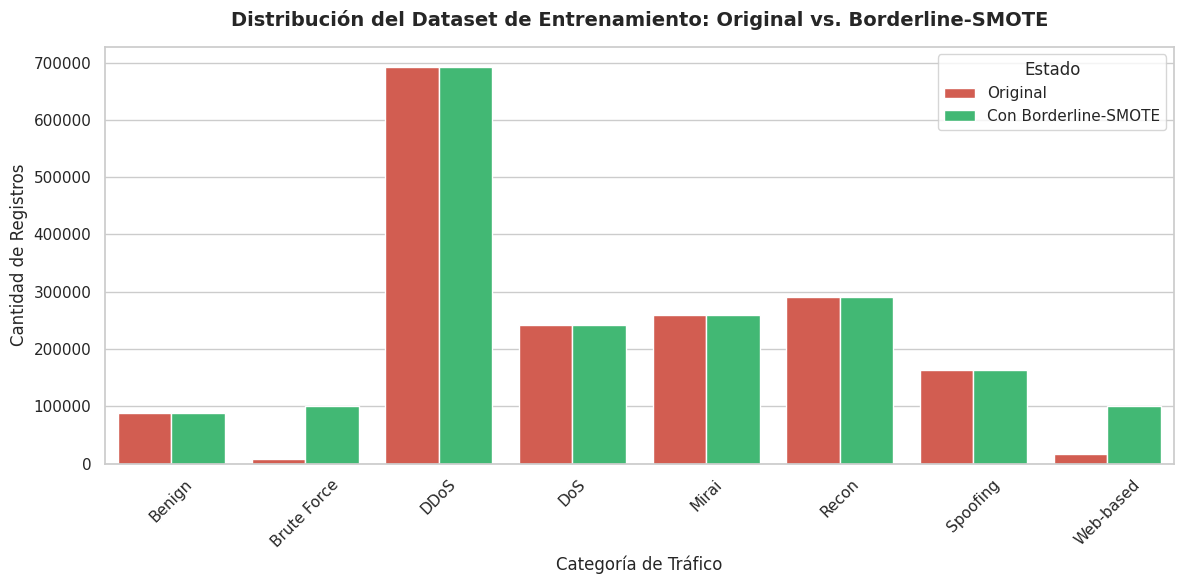

In [10]:
# Graficar comparación de distribuciones
df_plot = pd.DataFrame({
    'Clase': [class_names[i] for i in range(len(class_names))] * 2,
    'Cantidad': list(original_counts) + list(balanced_counts),
    'Estado': ['Original'] * len(class_names) + ['Con Borderline-SMOTE'] * len(class_names)
})

plt.figure(figsize=(12, 6))
sns.barplot(data=df_plot, x='Clase', y='Cantidad', hue='Estado', palette=['#E74C3C', '#2ECC71'])
plt.title("Distribución del Dataset de Entrenamiento: Original vs. Borderline-SMOTE", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Categoría de Tráfico")
plt.ylabel("Cantidad de Registros")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("results/figures/15_distribucion_borderline_smote.png", dpi=300)
plt.show()